In [3]:
import re
import string
import numpy as np
import pandas as pd

import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from tqdm.auto import tqdm

tqdm.pandas()

e:\interview preparation guide\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [102]:
questions = pd.read_csv('data/processed/question_info.csv')

In [103]:
missing = (
    questions
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing

solution                2567
solution_code_python    2524
solution_code_cpp       2362
description              714
likes                    208
dislikes                 208
stats                    208
similar_questions        208
hints                    208
category                 208
solution_url             200
difficulty               200
paidOnly                 200
ID                         0
frequency_pct              0
acceptance_pct             0
Difficulty                 0
Title                      0
URL                        0
difficulty_score           0
topics                     0
question_id                0
dtype: int64

In [104]:
questions.head()

,ID,URL,Title,Difficulty,acceptance_pct,frequency_pct,difficulty_score,difficulty,paidOnly,description,...,solution_code_python,solution_code_cpp,category,topics,hints,likes,dislikes,similar_questions,stats,question_id
0,2938,https://leetcode.com/problems/separate-black-a...,Separate Black and White Balls,Medium,63.9,100.0,2,Medium,False,"<p>There are <code>n</code> balls on a table, ...",...,NaN,NaN,Algorithms,"['Two Pointers', 'String', 'Greedy']",['Every <code>1</code> in the string <code>s</...,832.0,41.0,[],"{""totalAccepted"": ""170.7K"", ""totalSubmission"":...",1
1,2571,https://leetcode.com/problems/minimum-operatio...,Minimum Operations to Reduce an Integer to 0,Medium,62.4,100.0,2,Medium,False,<p>You are given a positive integer <code>n</c...,...,NaN,NaN,Algorithms,"['Dynamic Programming', 'Greedy', 'Bit Manipul...",['Can we set/unset the bits in binary represen...,561.0,193.0,"[{""title"": ""Plus One"", ""titleSlug"": ""plus-one""...","{""totalAccepted"": ""35.4K"", ""totalSubmission"": ...",2
2,1105,https://leetcode.com/problems/filling-bookcase...,Filling Bookcase Shelves,Medium,68.6,87.5,2,Medium,False,<p>You are given an array <code>books</code> w...,...,NaN,NaN,Algorithms,"['Array', 'Dynamic Programming']",['Use dynamic programming: dp(i) will be the ...,2603.0,255.0,[],"{""totalAccepted"": ""149.7K"", ""totalSubmission"":...",3
3,1894,https://leetcode.com/problems/find-the-student...,Find the Student that Will Replace the Chalk,Medium,53.2,87.5,2,Medium,False,<p>There are <code>n</code> students in a clas...,...,NaN,NaN,Algorithms,"['Array', 'Binary Search', 'Simulation', 'Pref...",['Subtract the sum of chalk from k until k is ...,1189.0,134.0,"[{""title"": ""Pass the Pillow"", ""titleSlug"": ""pa...","{""totalAccepted"": ""198K"", ""totalSubmission"": ""...",4
4,1497,https://leetcode.com/problems/check-if-array-p...,Check If Array Pairs Are Divisible by k,Medium,46.2,87.5,2,Medium,False,<p>Given an array of integers <code>arr</code>...,...,NaN,NaN,Algorithms,"['Array', 'Hash Table', 'Counting']",['Keep an array of the frequencies of ((x % k)...,2537.0,153.0,"[{""title"": ""Count Array Pairs Divisible by K"",...","{""totalAccepted"": ""197.2K"", ""totalSubmission"":...",5


In [105]:
text_cols = [
    "Title",
    "description",
    "topics",
    "hints",
    "similar_questions",
    "category"
]

for col in text_cols:
    questions[col] = questions[col].fillna("")

In [106]:
text_df = questions[
    [
        "ID",
        "Title",
        "description",
        "topics",
        "category",
        "hints",
        "similar_questions"
    ]
].copy()

In [107]:
questions.info()

<class 'pandas.DataFrame'>
RangeIndex: 3358 entries, 0 to 3357
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    3358 non-null   int64  
 1   URL                   3358 non-null   str    
 2   Title                 3358 non-null   str    
 3   Difficulty            3358 non-null   str    
 4   acceptance_pct        3358 non-null   float64
 5   frequency_pct         3358 non-null   float64
 6   difficulty_score      3358 non-null   int64  
 7   difficulty            3158 non-null   str    
 8   paidOnly              3158 non-null   object 
 9   description           3358 non-null   str    
 10  solution_url          3158 non-null   str    
 11  solution              791 non-null    str    
 12  solution_code_python  834 non-null    str    
 13  solution_code_cpp     996 non-null    str    
 14  category              3358 non-null   str    
 15  topics                3358 non-n

In [108]:
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words("english"))

In [109]:
def clean_text(text):

    text = str(text)

    # lowercase
    text = text.lower()

    # remove html
    text = re.sub(r"<.*?>", " ", text)

    # remove urls
    text = re.sub(r"http\S+", " ", text)

    # remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # remove digits
    text = re.sub(r"\d+", " ", text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text)

    words = []

    for word in text.split():

        if word not in stop_words:

            word = lemmatizer.lemmatize(word)

            words.append(word)

    return " ".join(words)

In [110]:
cols = [
    "Title",
    "description",
    "topics",
    "category",
    "hints",
    "similar_questions"
]

for col in cols:

    print(f"Cleaning {col}")

    text_df[col] = text_df[col].progress_apply(clean_text)

Cleaning Title


100%|██████████| 3358/3358 [00:00<00:00, 6789.17it/s]


Cleaning description


100%|██████████| 3358/3358 [00:03<00:00, 977.56it/s] 


Cleaning topics


...

100%|██████████| 3358/3358 [00:00<00:00, 35673.51it/s]


Cleaning hints


100%|██████████| 3358/3358 [00:00<00:00, 4797.99it/s]


Cleaning similar_questions


100%|██████████| 3358/3358 [00:00<00:00, 3869.65it/s]


In [111]:
text_df["corpus"] = (

    "TITLE " + text_df["Title"]

    + " CATEGORY " + text_df["category"]

    + " TOPICS " + text_df["topics"]

    + " DESCRIPTION " + text_df["description"]

    + " HINTS " + text_df["hints"]

    + " SIMILAR " + text_df["similar_questions"]

)

In [112]:
text_df["length"] = text_df["corpus"].str.split().apply(len)

text_df["length"].describe()

count    3358.000000
mean      127.381179
std        70.729338
min         9.000000
25%        80.000000
50%       127.000000
75%       170.000000
max       457.000000
Name: length, dtype: float64

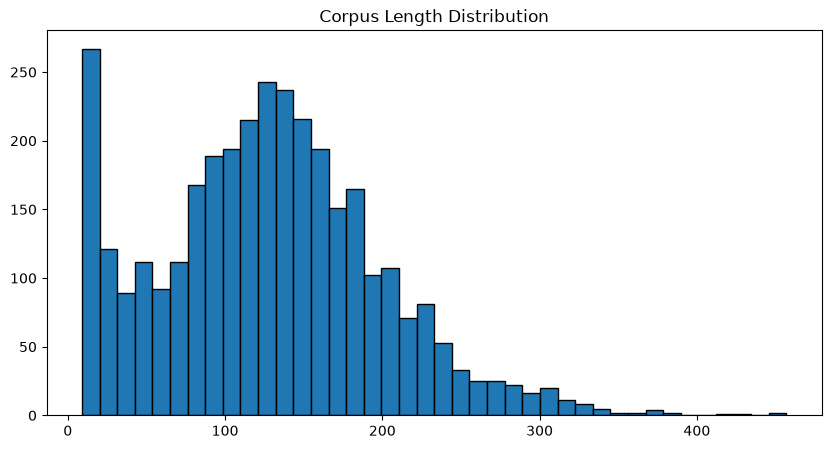

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    text_df["length"],
    bins=40,
    edgecolor="black"
)

plt.title("Corpus Length Distribution")

plt.show()

In [114]:
text_df.nlargest(
    10,
    "length"
)[["Title","length"]]

,Title,length
1143,sequentially ordinal rank tracker,457
1370,minimum cost convert string ii,455
2520,throne inheritance,427
1978,time network becomes idle,415
278,parse lisp expression,386
2444,remove comment,385
9,two sum,374
638,exclusive time function,371
1969,design movie rental system,371
3141,maximum good people based statement,369


In [115]:
text_df.nsmallest(
    10,
    "length"
)[["Title","length"]]

,Title,length
2399,better compression string,9
2705,top three winery,9
2932,remove,9
3168,filter character frequency,9
3316,maximum coin collection,9
296,find diameter endpoint tree,10
633,swap sex employee,10
973,npv query,10
1019,warehouse manager,10
1090,adfree session,10


In [116]:
text_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3358 entries, 0 to 3357
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID                 3358 non-null   int64
 1   Title              3358 non-null   str  
 2   description        3358 non-null   str  
 3   topics             3358 non-null   str  
 4   category           3358 non-null   str  
 5   hints              3358 non-null   str  
 6   similar_questions  3358 non-null   str  
 7   corpus             3358 non-null   str  
 8   length             3358 non-null   int64
dtypes: int64(2), str(7)
memory usage: 236.2 KB


In [56]:
text_df.to_csv(
    "clean_question_corpus.csv",
    index=False
)

## TF IDF

In [26]:
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

In [57]:
text_df.head()

,ID,Title,description,topics,category,hints,similar_questions,corpus,length
0,2938,separate black white ball,n ball table ball color black white given inde...,two pointer string greedy,algorithm,every string swapped every right side iterate ...,,TITLE separate black white ball CATEGORY algor...,134
1,2571,minimum operation reduce integer,given positive integer n following operation n...,dynamic programming greedy bit manipulation,algorithm,setunset bit binary representation multiple ad...,title plus one titleslug plusone difficulty ea...,TITLE minimum operation reduce integer CATEGOR...,121
2,1105,filling bookcase shelf,given array book booksi thickness height indic...,array dynamic programming,algorithm,use dynamic programming dpi answer problem booksi,,TITLE filling bookcase shelf CATEGORY algorith...,144
3,1894,find student replace chalk,n student class numbered n teacher give studen...,array binary search simulation prefix sum,algorithm,subtract sum chalk k k less sum chalk iterate ...,title pas pillow titleslug passthepillow diffi...,TITLE find student replace chalk CATEGORY algo...,230
4,1497,check array pair divisible k,given array integer arr even length n integer ...,array hash table counting,algorithm,keep array frequency x k k k x arr k need chec...,title count array pair divisible k titleslug c...,TITLE check array pair divisible k CATEGORY al...,157


In [117]:
print(text_df.shape)
print(text_df.isnull().sum())

(3358, 9)
ID                   0
Title                0
description          0
topics               0
category             0
hints                0
similar_questions    0
corpus               0
length               0
dtype: int64


In [118]:
tfidf = TfidfVectorizer(
    max_features=10000,      # limit vocab
    ngram_range=(1,2),       # unigrams + bigrams
    min_df=2,                # ignore rare words
    max_df=0.85,             # ignore very common words
    sublinear_tf=True        # log scaling
)

In [119]:
df = text_df.copy()

In [120]:
X_tfidf = tfidf.fit_transform(df["corpus"])

In [121]:
print(X_tfidf.shape)

(3358, 10000)


In [122]:
similarity_matrix = cosine_similarity(X_tfidf)

In [123]:
similarity_matrix.shape


(3358, 3358)

In [124]:
id_to_index = pd.Series(df.index, index=df["ID"]).to_dict()

In [128]:
def get_similar_questions(question_id, top_k=10):

    idx = id_to_index[question_id]

    scores = list(enumerate(similarity_matrix[idx]))

    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    scores = scores[1:top_k+1]  # remove self

    results = []

    for i, score in scores:
        id = df.iloc[i]["ID"]
        results.append({
            "question_id": df.iloc[i]["ID"],
            "title": questions.loc[questions['ID']==id,'Title'].iloc[0],
            "score": score
        })

    return pd.DataFrame(results)

In [75]:
df[df["Title"].str.contains("Two Sum", case=False)].head()

,ID,Title,description,topics,category,hints,similar_questions,corpus,length
9,1,two sum,given array integer nums nbspand integer targe...,array hash table,algorithm,really brute force way would search possible p...,title sum titleslug sum difficulty medium tran...,TITLE two sum CATEGORY algorithm TOPICS array ...,374
188,167,two sum ii input array sorted,given indexed array integer number already sor...,array two pointer binary search,algorithm,,title two sum titleslug twosum difficulty easy...,TITLE two sum ii input array sorted CATEGORY a...,159
648,653,two sum iv input bst,given root binary search tree integer k return...,hash table two pointer tree depthfirst search ...,algorithm,,title two sum titleslug twosum difficulty easy...,TITLE two sum iv input bst CATEGORY algorithm ...,122
812,1099,two sum less k,,array two pointer binary search sorting,algorithm,array sorted loop array get value ai need find...,title two sum titleslug twosum difficulty easy...,TITLE two sum less k CATEGORY algorithm TOPICS...,82
847,1214,two sum bsts,,two pointer binary search stack tree depthfirs...,algorithm,reduce problem classical two sum problem inord...,title two sum iv input bst titleslug twosumivi...,TITLE two sum bsts CATEGORY algorithm TOPICS t...,52


In [211]:
test_questions = [
    "Two Sum",
    "LRU Cache",
    "Sorting Three Groups",
    "Filling Bookcase Shelves",
    "Number of Islands"
]

In [212]:
for q in test_questions:

    print("\n====================")
    print("QUERY:", q)

    qid = questions[questions["Title"].str.contains(q, case=False)].iloc[0]["ID"]

    display(get_similar_questions(qid))


QUERY: Two Sum


,question_id,title,score
0,1748,Sum of Unique Elements,0.840986
1,2195,Append K Integers With Minimal Sum,0.807568
2,41,First Missing Positive,0.800483
3,1679,Max Number of K-Sum Pairs,0.795007
4,2395,Find Subarrays With Equal Sum,0.794268
5,2918,Minimum Equal Sum of Two Arrays After Replacin...,0.788798
6,560,Subarray Sum Equals K,0.787898
7,1480,Running Sum of 1d Array,0.785441
8,16,3Sum Closest,0.782967
9,2235,Add Two Integers,0.782497



QUERY: LRU Cache


,question_id,title,score
0,460,LFU Cache,0.921381
1,432,All O`one Data Structure,0.680782
2,705,Design HashSet,0.644432
3,706,Design HashMap,0.633549
4,138,Copy List with Random Pointer,0.624116
5,2502,Design Memory Allocator,0.621477
6,142,Linked List Cycle II,0.606732
7,2095,Delete the Middle Node of a Linked List,0.599508
8,141,Linked List Cycle,0.577549
9,2349,Design a Number Container System,0.572820



QUERY: Sorting Three Groups


,question_id,title,score
0,3190,Find Minimum Operations to Make All Elements D...,0.848544
1,217,Contains Duplicate,0.814080
2,3397,Maximum Number of Distinct Elements After Oper...,0.800519
3,268,Missing Number,0.795531
4,229,Majority Element II,0.790701
5,3105,Longest Strictly Increasing or Strictly Decrea...,0.786188
6,1887,Reduction Operations to Make the Array Element...,0.777537
7,2366,Minimum Replacements to Sort the Array,0.773691
8,3011,Find if Array Can Be Sorted,0.773383
9,2855,Minimum Right Shifts to Sort the Array,0.773038



QUERY: Filling Bookcase Shelves


,question_id,title,score
0,2355,Maximum Number of Books You Can Take,0.731701
1,1642,Furthest Building You Can Reach,0.624312
2,1051,Height Checker,0.622004
3,2037,Minimum Number of Moves to Seat Everyone,0.608502
4,1840,Maximum Building Height,0.605227
5,2866,Beautiful Towers II,0.599063
6,2147,Number of Ways to Divide a Long Corridor,0.597084
7,2226,Maximum Candies Allocated to K Children,0.594317
8,2865,Beautiful Towers I,0.591160
9,2771,Longest Non-decreasing Subarray From Two Arrays,0.586987



QUERY: Number of Islands


,question_id,title,score
0,1254,Number of Closed Islands,0.908252
1,1905,Count Sub Islands,0.898979
2,695,Max Area of Island,0.872954
3,827,Making A Large Island,0.820211
4,934,Shortest Bridge,0.793946
5,463,Island Perimeter,0.738911
6,1970,Last Day Where You Can Still Cross,0.730549
7,1020,Number of Enclaves,0.728021
8,1568,Minimum Number of Days to Disconnect Island,0.727155
9,1765,Map of Highest Peak,0.712066


In [147]:

questions.loc[questions['ID']==3229]

,ID,URL,Title,Difficulty,acceptance_pct,frequency_pct,difficulty_score,difficulty,paidOnly,description,...,solution_code_python,solution_code_cpp,category,topics,hints,likes,dislikes,similar_questions,stats,question_id
1486,3229,https://leetcode.com/problems/minimum-operatio...,Minimum Operations to Make Array Equal to Target,Hard,41.6,12.5,3,Hard,False,<p>You are given two positive integer arrays <...,...,NaN,NaN,Algorithms,"['Array', 'Dynamic Programming', 'Stack', 'Gre...","[""Change <code>nums'[i] = nums[i] - target[i]<...",230.0,8.0,[],"{""totalAccepted"": ""17.8K"", ""totalSubmission"": ...",1487


In [148]:
param_grid = [
    {"ngram_range": (1,1), "max_features": 5000},
    {"ngram_range": (1,2), "max_features": 5000},
    {"ngram_range": (1,2), "max_features": 10000},
    {"ngram_range": (1,3), "max_features": 10000},
]

In [149]:
def evaluate_model(vectorizer):

    X = vectorizer.fit_transform(df["corpus"])
    sim = cosine_similarity(X)

    scores = []

    for i in range(50):  # sample questions

        top_sim = np.sort(sim[i])[::-1][1:6]

        scores.append(np.mean(top_sim))

    return np.mean(scores)

In [150]:
for params in param_grid:

    tfidf = TfidfVectorizer(**params)

    score = evaluate_model(tfidf)

    print(params, score)

{'ngram_range': (1, 1), 'max_features': 5000} 0.5308897429864293
{'ngram_range': (1, 2), 'max_features': 5000} 0.5104912463803103
{'ngram_range': (1, 2), 'max_features': 10000} 0.46887276538986894
{'ngram_range': (1, 3), 'max_features': 10000} 0.46864221454125693


In [157]:
import joblib

joblib.dump(tfidf, "models/tfidf_vectorizer.pkl")
np.save("tfidf_matrix.npy", X_tfidf.toarray())

## SENTENCE TRANSFORMER

In [163]:
import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

import joblib

In [180]:
text_df = questions[
    [
        "ID",
        "Title",
        "description",
        "topics",
        "category",
        "hints",
        "similar_questions",
        "Difficulty",
        "acceptance_pct",
        "frequency_pct"
    ]
].copy()

In [182]:
text_df["corpus"] = (

    "TITLE " + text_df["Title"]

    + " CATEGORY " + text_df["category"]

    + " TOPICS " + text_df["topics"]

    + " DESCRIPTION " + text_df["description"]

    + " HINTS " + text_df["hints"]

    + " SIMILAR " + text_df["similar_questions"]
    + "DIFFICULTY" + text_df["Difficulty"]
    + "ACCEPTANCE RATE" + str(text_df['acceptance_pct'])
    + "FREQUENCY PERCENTAGE" + str(text_df['frequency_pct'])

)

In [183]:
questions.info()

<class 'pandas.DataFrame'>
RangeIndex: 3358 entries, 0 to 3357
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    3358 non-null   int64  
 1   URL                   3358 non-null   str    
 2   Title                 3358 non-null   str    
 3   Difficulty            3358 non-null   str    
 4   acceptance_pct        3358 non-null   float64
 5   frequency_pct         3358 non-null   float64
 6   difficulty_score      3358 non-null   int64  
 7   difficulty            3158 non-null   str    
 8   paidOnly              3158 non-null   object 
 9   description           3358 non-null   str    
 10  solution_url          3158 non-null   str    
 11  solution              791 non-null    str    
 12  solution_code_python  834 non-null    str    
 13  solution_code_cpp     996 non-null    str    
 14  category              3358 non-null   str    
 15  topics                3358 non-n

In [197]:
text_df.head()

,ID,Title,description,topics,category,hints,similar_questions,Difficulty,acceptance_pct,frequency_pct,corpus
0,2938,Separate Black and White Balls,"<p>There are <code>n</code> balls on a table, ...","['Two Pointers', 'String', 'Greedy']",Algorithms,['Every <code>1</code> in the string <code>s</...,[],Medium,63.9,100.0,TITLE Separate Black and White Balls CATEGORY ...
1,2571,Minimum Operations to Reduce an Integer to 0,<p>You are given a positive integer <code>n</c...,"['Dynamic Programming', 'Greedy', 'Bit Manipul...",Algorithms,['Can we set/unset the bits in binary represen...,"[{""title"": ""Plus One"", ""titleSlug"": ""plus-one""...",Medium,62.4,100.0,TITLE Minimum Operations to Reduce an Integer ...
2,1105,Filling Bookcase Shelves,<p>You are given an array <code>books</code> w...,"['Array', 'Dynamic Programming']",Algorithms,['Use dynamic programming: dp(i) will be the ...,[],Medium,68.6,87.5,TITLE Filling Bookcase Shelves CATEGORY Algori...
3,1894,Find the Student that Will Replace the Chalk,<p>There are <code>n</code> students in a clas...,"['Array', 'Binary Search', 'Simulation', 'Pref...",Algorithms,['Subtract the sum of chalk from k until k is ...,"[{""title"": ""Pass the Pillow"", ""titleSlug"": ""pa...",Medium,53.2,87.5,TITLE Find the Student that Will Replace the C...
4,1497,Check If Array Pairs Are Divisible by k,<p>Given an array of integers <code>arr</code>...,"['Array', 'Hash Table', 'Counting']",Algorithms,['Keep an array of the frequencies of ((x % k)...,"[{""title"": ""Count Array Pairs Divisible by K"",...",Medium,46.2,87.5,TITLE Check If Array Pairs Are Divisible by k ...


In [184]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2084.86it/s]


In [198]:
embeddings = model.encode(
    text_df["corpus"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True   #Now cosine similarity becomes much faster and numerically stable.
)

Batches:   0%|          | 0/105 [00:00<?, ?it/s]

Batches: 100%|██████████| 105/105 [04:03<00:00,  2.32s/it]


In [199]:
embeddings.shape

(3358, 384)

In [200]:
np.save("question_embeddings.npy", embeddings)

In [1]:
metadata1 = questions[
    [
        "ID",
        "Title"
    ]
]

metadata1.to_csv(
    "embedding_metadata_1.csv",
    index=False
)

NameError: name 'questions' is not defined

In [202]:
similarity_matrix = cosine_similarity(embeddings)

In [203]:
id_to_index = pd.Series(
    df.index,
    index=df.ID
).to_dict()

In [204]:
def semantic_search(question_id, top_k=10):

    idx = id_to_index[question_id]

    sims = similarity_matrix[idx]

    top_idx = np.argsort(sims)[::-1][1:top_k+1]

    result = text_df.loc[
        top_idx,
        [
            "ID",
            "Title",
            "topics",
            "Difficulty"
        ]
    ].copy()

    result["similarity"] = sims[top_idx]

    return result

In [205]:
queries = [
    "Two Sum",
    "LRU Cache",
    "Number of Islands",
    "Merge Intervals",
    "Course Schedule",
    "Binary Tree Maximum Path Sum"
]

In [206]:
for q in queries:

    print("="*80)
    print(q)

    qid = text_df[
        text_df.Title.str.contains(
            q,
            case=False
        )
    ].iloc[0].ID

    display(
        semantic_search(qid)
    )

Two Sum


,ID,Title,topics,Difficulty,similarity
1487,1748,Sum of Unique Elements,"['Array', 'Hash Table', 'Counting']",Easy,0.840986
1163,2195,Append K Integers With Minimal Sum,"['Array', 'Math', 'Greedy', 'Sorting']",Medium,0.807568
379,41,First Missing Positive,"['Array', 'Hash Table']",Hard,0.800483
1046,1679,Max Number of K-Sum Pairs,"['Array', 'Hash Table', 'Two Pointers', 'Sorti...",Medium,0.795007
2183,2395,Find Subarrays With Equal Sum,"['Array', 'Hash Table']",Easy,0.794268
1626,2918,Minimum Equal Sum of Two Arrays After Replacin...,"['Array', 'Greedy']",Medium,0.788798
138,560,Subarray Sum Equals K,"['Array', 'Hash Table', 'Prefix Sum']",Medium,0.787898
985,1480,Running Sum of 1d Array,"['Array', 'Prefix Sum']",Easy,0.785441
372,16,3Sum Closest,"['Array', 'Two Pointers', 'Sorting']",Medium,0.782967
125,2235,Add Two Integers,['Math'],Easy,0.782497


LRU Cache


,ID,Title,topics,Difficulty,similarity
572,460,LFU Cache,"['Hash Table', 'Linked List', 'Design', 'Doubl...",Hard,0.921381
334,432,All O`one Data Structure,"['Hash Table', 'Linked List', 'Design', 'Doubl...",Hard,0.680782
709,705,Design HashSet,"['Array', 'Hash Table', 'Linked List', 'Design...",Easy,0.644432
710,706,Design HashMap,"['Array', 'Hash Table', 'Linked List', 'Design...",Easy,0.633549
426,138,Copy List with Random Pointer,"['Hash Table', 'Linked List']",Medium,0.624116
1254,2502,Design Memory Allocator,"['Array', 'Hash Table', 'Design', 'Simulation']",Medium,0.621477
429,142,Linked List Cycle II,"['Hash Table', 'Linked List', 'Two Pointers']",Medium,0.606732
1145,2095,Delete the Middle Node of a Linked List,"['Linked List', 'Two Pointers']",Medium,0.599508
113,141,Linked List Cycle,"['Hash Table', 'Linked List', 'Two Pointers']",Easy,0.577549
2605,2349,Design a Number Container System,"['Hash Table', 'Design', 'Heap (Priority Queue...",Medium,0.572820


Number of Islands


...

,ID,Title,topics,Difficulty,similarity
556,435,Non-overlapping Intervals,"['Array', 'Dynamic Programming', 'Greedy', 'So...",Medium,0.926526
872,1288,Remove Covered Intervals,"['Array', 'Sorting']",Medium,0.868256
1825,757,Set Intersection Size At Least Two,"['Array', 'Greedy', 'Sorting']",Hard,0.838044
384,57,Insert Interval,['Array'],Medium,0.833410
793,986,Interval List Intersections,"['Array', 'Two Pointers', 'Line Sweep']",Medium,0.792349
227,2406,Divide Intervals Into Minimum Number of Groups,"['Array', 'Two Pointers', 'Greedy', 'Sorting',...",Medium,0.783755
557,436,Find Right Interval,"['Array', 'Binary Search', 'Sorting']",Medium,0.770674
3289,2121,Intervals Between Identical Elements,"['Array', 'Hash Table', 'Prefix Sum']",Medium,0.745303
2948,2580,Count Ways to Group Overlapping Ranges,"['Array', 'Sorting']",Medium,0.731815
1591,3414,Maximum Score of Non-overlapping Intervals,"['Array', 'Binary Search', 'Dynamic Programmin...",Hard,0.712716


Course Schedule


,ID,Title,topics,Difficulty,similarity
461,210,Course Schedule II,"['Depth-First Search', 'Breadth-First Search',...",Medium,0.994393
1523,1462,Course Schedule IV,"['Depth-First Search', 'Breadth-First Search',...",Medium,0.991602
2022,1494,Parallel Courses II,"['Dynamic Programming', 'Bit Manipulation', 'G...",Hard,0.826872
635,630,Course Schedule III,"['Array', 'Greedy', 'Sorting', 'Heap (Priority...",Hard,0.807786
159,2050,Parallel Courses III,"['Array', 'Dynamic Programming', 'Graph', 'Top...",Hard,0.787365
2856,1964,Find the Longest Valid Obstacle Course at Each...,"['Array', 'Binary Search', 'Binary Indexed Tree']",Hard,0.673500
542,399,Evaluate Division,"['Array', 'String', 'Depth-First Search', 'Bre...",Medium,0.641728
3160,2642,Design Graph With Shortest Path Calculator,"['Graph', 'Design', 'Heap (Priority Queue)', '...",Hard,0.635661
2544,1786,Number of Restricted Paths From First to Last ...,"['Dynamic Programming', 'Graph', 'Topological ...",Medium,0.634271
1896,565,Array Nesting,"['Array', 'Depth-First Search']",Medium,0.630262


Binary Tree Maximum Path Sum


,ID,Title,topics,Difficulty,similarity
832,1161,Maximum Level Sum of a Binary Tree,"['Tree', 'Depth-First Search', 'Breadth-First ...",Medium,0.870353
414,113,Path Sum II,"['Backtracking', 'Tree', 'Depth-First Search',...",Medium,0.869230
558,437,Path Sum III,"['Tree', 'Depth-First Search', 'Binary Tree']",Medium,0.863875
1918,687,Longest Univalue Path,"['Tree', 'Depth-First Search', 'Binary Tree']",Medium,0.845919
413,112,Path Sum,"['Tree', 'Depth-First Search', 'Breadth-First ...",Easy,0.845508
31,104,Maximum Depth of Binary Tree,"['Tree', 'Depth-First Search', 'Breadth-First ...",Easy,0.842695
882,1302,Deepest Leaves Sum,"['Tree', 'Depth-First Search', 'Breadth-First ...",Medium,0.842612
947,1373,Maximum Sum BST in Binary Tree,"['Dynamic Programming', 'Tree', 'Depth-First S...",Hard,0.842273
851,1080,Insufficient Nodes in Root to Leaf Paths,"['Tree', 'Depth-First Search', 'Binary Tree']",Medium,0.824785
1262,2583,Kth Largest Sum in a Binary Tree,"['Tree', 'Breadth-First Search', 'Sorting', 'B...",Medium,0.821006


## COMPARISION

In [208]:
tfidf = joblib.load("models/tfidf_vectorizer.pkl")

tfidf_matrix = np.load("tfidf_matrix.npy")

In [209]:
tfidf_similarity = cosine_similarity(tfidf_matrix)

In [ ]:
def compare_models(question_id):

    idx = id_to_index[question_id]

    tfidf_idx = np.argsort(
        tfidf_similarity[idx]
    )[::-1][1:6]

    bert_idx = np.argsort(
        similarity_matrix[idx]
    )[::-1][1:6]

    print("\nTF-IDF")

    display(
        questions.loc[
            tfidf_idx,
            ["Title","topics"]
        ]
    )
    

    print("\nSentence Transformer")

    display(
        questions.loc[
            bert_idx,
            ["Title","topics"]
        ]
    )

In [219]:
qid = text_df[
        text_df.Title.str.contains(
            "LRU Cache",
            case=False
        )
    ].iloc[0].ID

compare_models(qid)


TF-IDF


,Title,topics
572,LFU Cache,"['Hash Table', 'Linked List', 'Design', 'Doubl..."
710,Design HashMap,"['Array', 'Hash Table', 'Linked List', 'Design..."
620,Design In-Memory File System,"['Hash Table', 'String', 'Design', 'Trie', 'So..."
2437,Design Compressed String Iterator,"['Array', 'String', 'Design', 'Iterator']"
709,Design HashSet,"['Array', 'Hash Table', 'Linked List', 'Design..."



Sentence Transformer


,Title,topics
572,LFU Cache,"['Hash Table', 'Linked List', 'Design', 'Doubl..."
334,All O`one Data Structure,"['Hash Table', 'Linked List', 'Design', 'Doubl..."
709,Design HashSet,"['Array', 'Hash Table', 'Linked List', 'Design..."
710,Design HashMap,"['Array', 'Hash Table', 'Linked List', 'Design..."
426,Copy List with Random Pointer,"['Hash Table', 'Linked List']"


In [220]:
questions.loc[questions['ID']==qid]['topics']

185    ['Hash Table', 'Linked List', 'Design', 'Doubl...
Name: topics, dtype: str

In [221]:
scores = []

for i in range(len(text_df)):

    sims = np.sort(
        similarity_matrix[i]
    )[::-1][1:6]

    scores.append(
        np.mean(sims)
    )

print(np.mean(scores))

0.77535915


In [222]:
scores1 = []

for i in range(len(df)):

    sims1 = np.sort(
        tfidf_similarity[i]
    )[::-1][1:6]

    scores1.append(
        np.mean(sims1)
    )

print(np.mean(scores1))

0.35495040115078147


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=42
)

X = pca.fit_transform(
    embeddings
)

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(
    embeddings
)

In [ ]:
def topic_overlap(query_idx, retrieved_idx):
    query_topics = set(questions.loc[query_idx, "topics"].split(","))

    overlaps = []

    for idx in retrieved_idx:
        cand_topics = set(questions.loc[idx, "topics"].split(","))

        overlaps.append(
            len(query_topics & cand_topics)
        )
    return np.mean(overlaps)

In [223]:
np.save(
    "question_embeddings.npy",
    embeddings
)

joblib.dump(
    similarity_matrix,
    "semantic_similarity.pkl"
)

['semantic_similarity.pkl']

In [224]:
joblib.dump(model, "models/sentence_transformer.pkl")

['models/sentence_transformer.pkl']